Обнаружение аномалий во временных рядах с использованием LSTM-автоэнкодеров на PyTorch

In [1]:
import torch
import copy
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from torch import nn, optim
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

ДАТАСЕТ

In [2]:
# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Загрузка данных в Kaggle

train_path = "/kaggle/input/heartbeat/mitbih_train.csv"
test_path = "/kaggle/input/heartbeat/mitbih_test.csv"


In [4]:
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
print("Data loaded successfully from Kaggle inputs")
# Проверка данных
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nFirst 5 rows of training data:")
print(train_df.head())


Data loaded successfully from Kaggle inputs
Train shape: (87554, 188)
Test shape: (21892, 188)

First 5 rows of training data:
        0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371 

ИССЛЕДОВАНИЕ

Number of Samples: 109446
Number of Categories: 5
Sampling Frequency: 125Hz
Data Source: Physionet's MIT-BIH Arrhythmia Dataset
Classes: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]

In [5]:
class_names = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion',
    4: 'Unclassifiable'
}

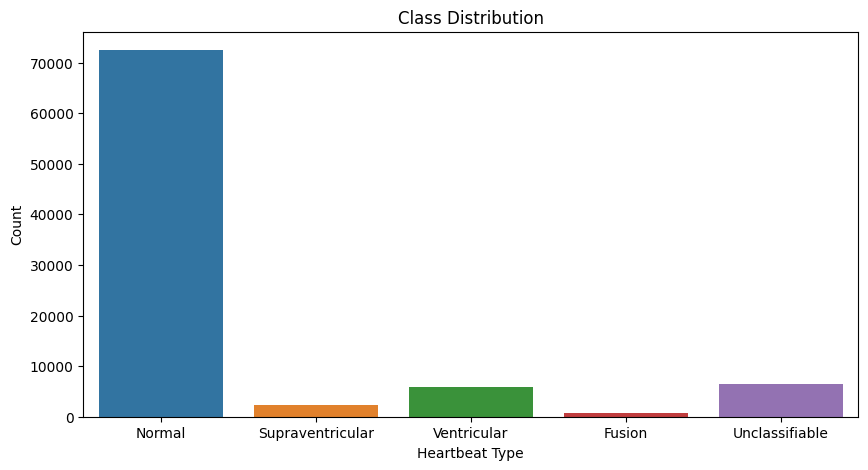

In [6]:
# Распределение классов
plt.figure(figsize=(10, 5))
sns.countplot(x=train_df.iloc[:, -1].map(class_names))
plt.title('Class Distribution')
plt.xlabel('Heartbeat Type')
plt.ylabel('Count')
plt.show()

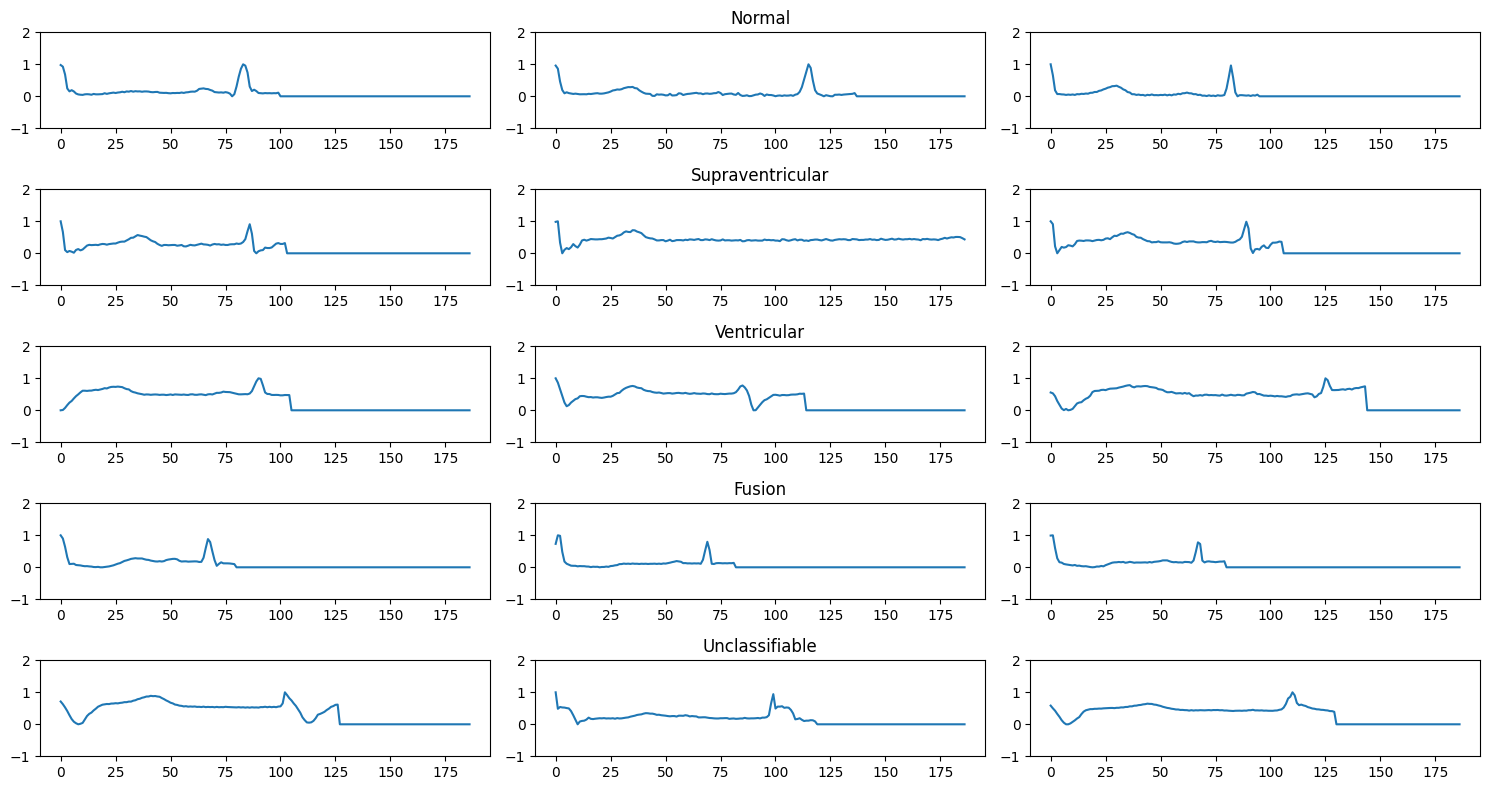

In [7]:
# Примеры сигналов
def plot_samples(data, labels, class_map, samples_per_class=3):
    plt.figure(figsize=(15, 8))
    for class_id, class_name in class_map.items():
        class_data = data[labels == class_id].iloc[:, :-1]
        for i in range(samples_per_class):
            plt.subplot(len(class_map), samples_per_class, 
                       class_id * samples_per_class + i + 1)
            plt.plot(class_data.iloc[i], linewidth=1.5)
            plt.title(f"{class_name}" if i == 1 else "")
            plt.ylim(-1, 2)
    plt.tight_layout()
    plt.show()

plot_samples(train_df, train_df.iloc[:, -1], class_names)

АВТОЭНКОДЕР


In [8]:
CLASS_NORMAL = 0  # Нормальные сокращения (класс 0), чтоб потом не искать
RANDOM_SEED = 42 # Номер сида
BATCH_SIZE = 256  # Подкручиваем батч, быстрее обучение

In [9]:
# Разделение на нормальные и аномальные
normal_df = train_df[train_df.iloc[:, -1] == CLASS_NORMAL].iloc[:, :-1]
anomaly_df = train_df[train_df.iloc[:, -1] != CLASS_NORMAL].iloc[:, :-1]
print(f"Normal samples: {len(normal_df)}, Anomaly samples: {len(anomaly_df)}")

Normal samples: 72471, Anomaly samples: 15083


In [10]:
# Разделение нормальных данных на train/val/test
train_df, val_df = train_test_split(
    normal_df,
    test_size=0.15,
    random_state=RANDOM_SEED
)

val_df, test_normal_df = train_test_split(
    val_df,
    test_size=0.33,
    random_state=RANDOM_SEED
)

In [11]:
# ТЕСТ
test_anomaly_df = test_df[test_df.iloc[:, -1] != CLASS_NORMAL].iloc[:, :-1]


In [12]:
# Масштабирование данных
scaler = MinMaxScaler()
train_df = scaler.fit_transform(train_df)
val_df = scaler.transform(val_df)
test_normal_df = scaler.transform(test_normal_df)
anomaly_df = scaler.transform(anomaly_df)
test_anomaly_df = scaler.transform(test_anomaly_df)

In [13]:
# Преобразование в тензоры
def create_tensor_dataset(data):
    tensor = torch.FloatTensor(data).unsqueeze(2)  # (samples, timesteps, features)
    return TensorDataset(tensor, tensor)  # Для автоэнкодера input == target

In [14]:
train_dataset = create_tensor_dataset(train_df)
val_dataset = create_tensor_dataset(val_df)
test_normal_dataset = create_tensor_dataset(test_normal_df)
test_anomaly_dataset = create_tensor_dataset(test_anomaly_df)

In [15]:
# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_normal_loader = DataLoader(test_normal_dataset, batch_size=1)
test_anomaly_loader = DataLoader(test_anomaly_dataset, batch_size=1)

In [16]:
print("\nData Loaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test normal samples: {len(test_normal_loader)}")
print(f"Test anomaly samples: {len(test_anomaly_loader)}")


Data Loaders created:
Train batches: 241
Validation batches: 29
Test normal samples: 3588
Test anomaly samples: 3774


ОБУЧЕНИЕ

In [17]:
import torch
import torch.nn as nn
from tqdm import tqdm


class Encoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.embedding_dim = embedding_dim
        self.hidden_dim = 2 * embedding_dim
        
        self.rnn1 = nn.LSTM(
            input_size=n_features,
            hidden_size=self.hidden_dim,
            num_layers=1,
            batch_first=True
        )
        
        self.rnn2 = nn.LSTM(
            input_size=self.hidden_dim,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True
        )
    
    def forward(self, x):
        x, _ = self.rnn1(x)
        x, (hidden_n, _) = self.rnn2(x)
        return hidden_n[-1]  # Берем последнее скрытое состояние

In [18]:
class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim=64, n_features=1):
        super().__init__()
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.n_features = n_features
        
        self.rnn = nn.LSTM(
            input_size=input_dim,
            hidden_size=input_dim,
            num_layers=1,
            batch_first=True
        )
        
        self.output_layer = nn.Linear(input_dim, n_features)
    
    def forward(self, x):
        # Подготовка входных данных для декодера
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        # Проход через LSTM слой
        x, _ = self.rnn(x)
        
        # Применяем линейный слой к каждому временному шагу
        return self.output_layer(x)


In [19]:
class LSTM_Autoencoder(nn.Module):
    def __init__(self, seq_len=187, n_features=1, embedding_dim=128):
        super().__init__()
        
        # Энкодер
        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=embedding_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.1
        )
        
        # Декодер
        self.decoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=embedding_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.1
        )
        
        self.fc = nn.Linear(embedding_dim, n_features)
        self.seq_len = seq_len

    def forward(self, x):
        # Энкодер
        _, (hidden, _) = self.encoder(x)
        
        # Подготовка скрытого состояния (повторяем для каждой временной точки)
        hidden = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        
        # Декодер
        out, _ = self.decoder(hidden)
        return self.fc(out)

In [20]:
model = LSTM_Autoencoder().to(device)
test_input = torch.randn(256, 187, 1).to(device)  # Пример батча
test_output = model(test_input)
print(f"Input shape: {test_input.shape}, Output shape: {test_output.shape}")

Input shape: torch.Size([256, 187, 1]), Output shape: torch.Size([256, 187, 1])


In [21]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [22]:
def train_model(model, train_loader, val_loader, n_epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss()
    history = {'train': [], 'val': []}
    best_loss = float('inf')
    
    for epoch in range(1, n_epochs + 1):
        # Training
        model.train()
        train_loss = 0
        for x, _ in tqdm(train_loader, desc=f'Epoch {epoch}/{n_epochs}'):
            x = x.to(device)
            
            optimizer.zero_grad()
            x_recon = model(x)
            loss = criterion(x_recon, x)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_recon = model(x)
                val_loss += criterion(x_recon, x).item()
        
        # Logging
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        
        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
        
        print(f'Epoch {epoch}: Train Loss: {train_loss:.5f}, Val Loss: {val_loss:.5f}')
    
    model.load_state_dict(torch.load('best_model.pth'))
    return model, history

In [23]:
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            x_recon = model(x)
            total_loss += F.l1_loss(x_recon, x).item()
    return total_loss / len(dataloader)

In [24]:
model = LSTM_Autoencoder().to(device)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    n_epochs=50  
)

Epoch 1/50: 100%|██████████| 241/241 [00:17<00:00, 13.92it/s]


Epoch 1: Train Loss: 0.13892, Val Loss: 0.11559


Epoch 2/50: 100%|██████████| 241/241 [00:16<00:00, 14.21it/s]


Epoch 2: Train Loss: 0.10769, Val Loss: 0.09951


Epoch 3/50: 100%|██████████| 241/241 [00:17<00:00, 13.92it/s]


...

Epoch 48: Train Loss: 0.02010, Val Loss: 0.01623


Epoch 49/50: 100%|██████████| 241/241 [00:19<00:00, 12.29it/s]


Epoch 49: Train Loss: 0.01965, Val Loss: 0.01567


Epoch 50/50: 100%|██████████| 241/241 [00:19<00:00, 12.37it/s]


Epoch 50: Train Loss: 0.01960, Val Loss: 0.01760


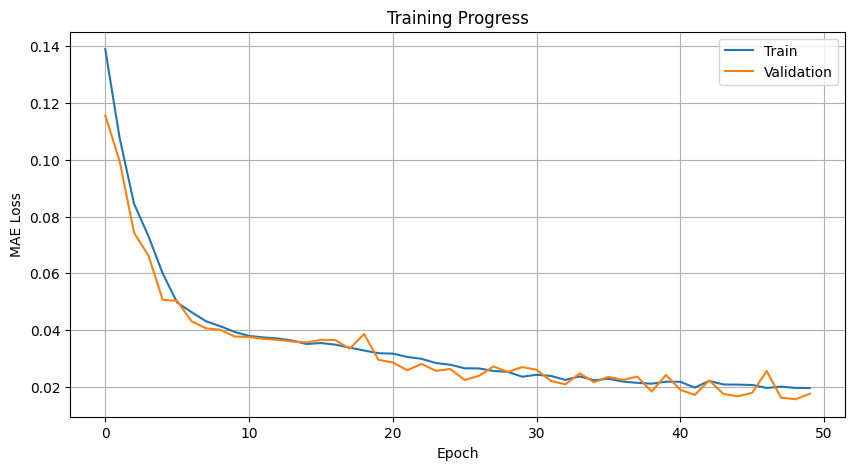

In [25]:
# Визуализация обучения
plt.figure(figsize=(10, 5))
plt.plot(history['train'], label='Train')
plt.plot(history['val'], label='Validation')
plt.ylabel('MAE Loss')
plt.xlabel('Epoch')
plt.legend()
plt.title('Training Progress')
plt.grid(True)
plt.show()

In [26]:
# import torch
# from datetime import datetime

# # 1. Создаем путь для сохранения с timestamp
# MODEL_DIR = '/kaggle/working/models/'
# MODEL_NAME = 'lstm_autoencoder'
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# MODEL_PATH = f"{MODEL_DIR}{MODEL_NAME}_{timestamp}.pth"

# # 2. Создаем директорию, если ее нет
# import os
# os.makedirs(MODEL_DIR, exist_ok=True)

# # 3. Сохраняем ВСЕ необходимые компоненты
# torch.save({
#     'epoch': 150,
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'train_loss': history['train'][-1],
#     'val_loss': history['val'][-1],
#     'model_config': {
#         'seq_len': 187,
#         'n_features': 1,
#         'embedding_dim': 128
#     },
#     'scaler_config': {
#         'min_': scaler.min_,
#         'scale_': scaler.scale_,
#         'data_min_': scaler.data_min_,
#         'data_max_': scaler.data_max_
#     }
# }, MODEL_PATH)

# print(f"Model saved to {MODEL_PATH}")

АНАЛИЗ ПОЛУЧЕННЫХ РЕЗУЛЬТАТОВ

In [27]:
def predict(model, dataloader):
    model.eval()
    predictions = []
    losses = []
    
    with torch.no_grad():
        for seq_true, _ in dataloader:  # Учитываем структуру DataLoader
            seq_true = seq_true.to(device)
            seq_pred = model(seq_true)
            
            # Вычисляем MAE для каждого примера
            loss = torch.mean(torch.abs(seq_pred - seq_true), dim=(1,2)).cpu().numpy()
            losses.extend(loss)
            predictions.append(seq_pred.cpu().numpy())
    
    return np.concatenate(predictions), np.array(losses)


In [28]:
THRESHOLD = 0.1  # Начальное значение порога

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


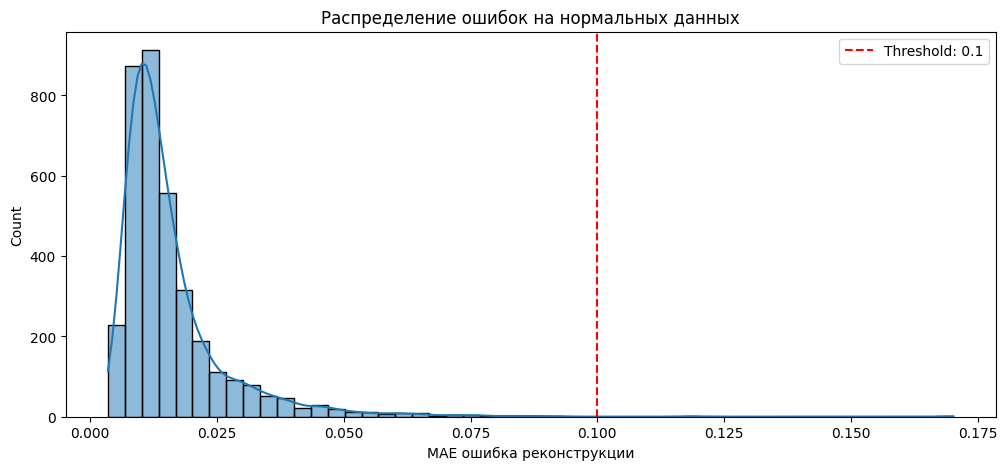

In [29]:

predictions, normal_losses = predict(model, test_normal_loader)
plt.figure(figsize=(12, 5))
sns.histplot(normal_losses, bins=50, kde=True)
plt.axvline(THRESHOLD, color='r', linestyle='--', label=f'Threshold: {THRESHOLD}')
plt.title('Распределение ошибок на нормальных данных')
plt.xlabel('MAE ошибка реконструкции')
plt.legend()
plt.show()

In [30]:
# Подсчет правильных предсказаний
correct_normal = sum(l <= THRESHOLD for l in normal_losses)
print(f'Правильно классифицировано нормальных: {correct_normal}/{len(test_normal_loader)}')
print(f'Точность: {correct_normal/len(test_normal_loader):.2%}')

Правильно классифицировано нормальных: 3586/3588
Точность: 99.94%


In [31]:
anomaly_subset = torch.utils.data.Subset(test_anomaly_dataset, indices=range(len(test_normal_dataset)))

In [32]:
anomaly_loader = DataLoader(
    anomaly_subset,
    batch_size=1,
    shuffle=False
)

In [33]:
_, anomaly_losses = predict(model, anomaly_loader)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


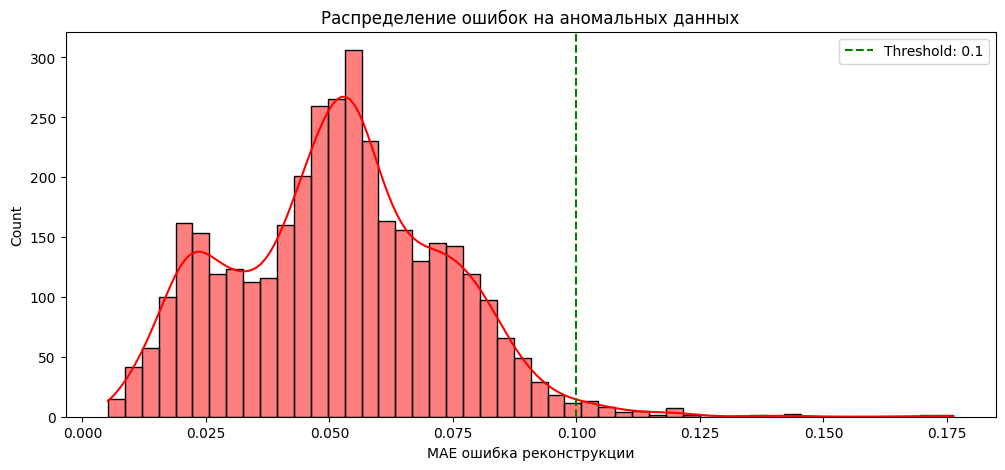

In [34]:
plt.figure(figsize=(12, 5))
sns.histplot(anomaly_losses, bins=50, kde=True, color='r')
plt.axvline(THRESHOLD, color='g', linestyle='--', label=f'Threshold: {THRESHOLD}')
plt.title('Распределение ошибок на аномальных данных')
plt.xlabel('MAE ошибка реконструкции')
plt.legend()
plt.show()

In [35]:
correct_anomaly = sum(l > THRESHOLD for l in anomaly_losses)
print(f'Правильно классифицировано аномалий: {correct_anomaly}/{len(anomaly_loader)}')
print(f'Точность: {correct_anomaly/len(anomaly_loader):.2%}')

Правильно классифицировано аномалий: 50/3588
Точность: 1.39%


АНАЛИЗ ПРИМЕРОВ

In [36]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(model, normal_loader, anomaly_loader, num_examples=3):
    plt.figure(figsize=(15, 4*num_examples))
    
    # Функция для построения одного графика
    def plot_single(ax, original, reconstructed, title, loss):
        ax.plot(original, label='Исходный', linewidth=2)
        ax.plot(reconstructed, label='Реконструированный', linestyle='--')
        ax.set_title(f'{title} (Ошибка: {loss:.4f})')
        ax.legend()
        ax.grid(True)
    
    # Нормальные примеры
    model.eval()
    with torch.no_grad():
        # Берем первые num_examples нормальных примеров
        for i, (data, _) in enumerate(normal_loader):
            if i >= num_examples:
                break
            data = data.to(device)
            recon = model(data)
            loss = torch.mean(torch.abs(data - recon)).item()
            
            ax = plt.subplot(num_examples, 2, 2*i+1)
            plot_single(ax, 
                      data[0].cpu().numpy().squeeze(), 
                      recon[0].cpu().numpy().squeeze(),
                      f'Нормальный пример {i+1}', 
                      loss)
        
        # Берем первые num_examples аномальных примеров
        for i, (data, _) in enumerate(anomaly_loader):
            if i >= num_examples:
                break
            data = data.to(device)
            recon = model(data)
            loss = torch.mean(torch.abs(data - recon)).item()
            
            ax = plt.subplot(num_examples, 2, 2*i+2)
            plot_single(ax, 
                      data[0].cpu().numpy().squeeze(), 
                      recon[0].cpu().numpy().squeeze(),
                      f'Аномальный пример {i+1}', 
                      loss)
    
    plt.tight_layout()
    plt.show()


In [37]:
normal_loader_single = DataLoader(
    test_normal_dataset,
    batch_size=1,
    shuffle=False
)

In [38]:
anomaly_loader_single = DataLoader(
    test_anomaly_dataset,
    batch_size=1,
    shuffle=False
)

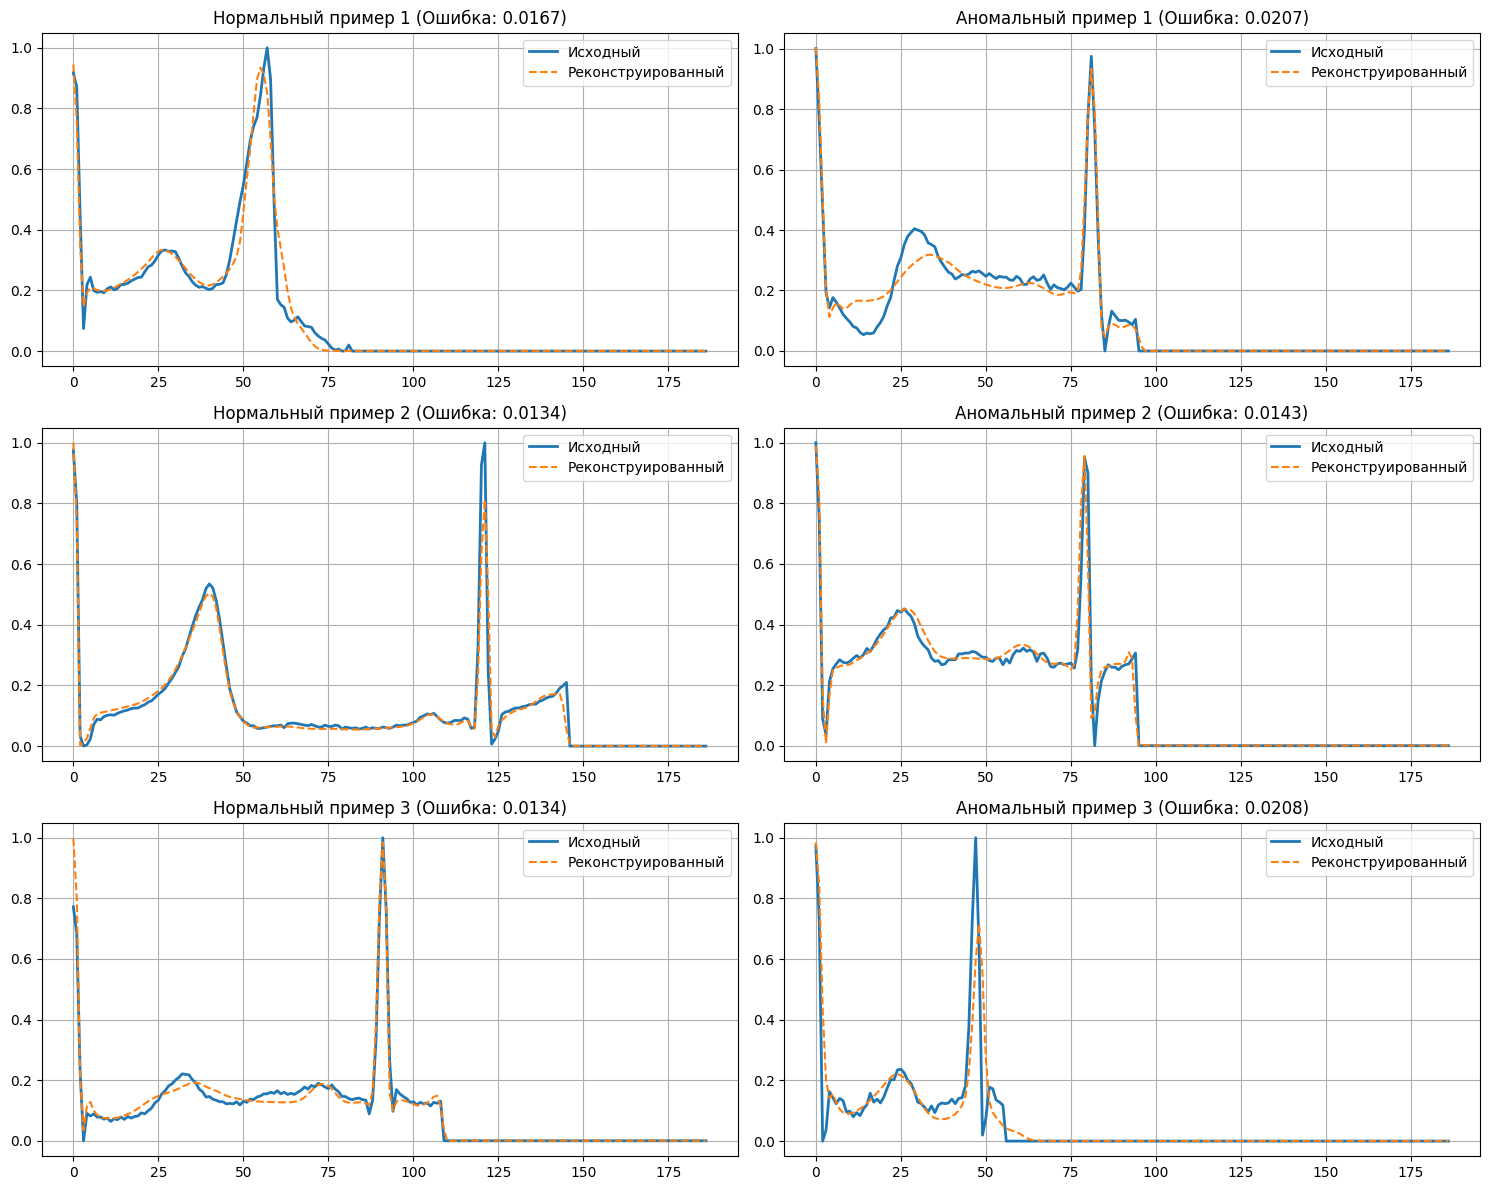

In [39]:
plot_predictions(model, normal_loader_single, anomaly_loader_single, num_examples=3)